In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from datamodelling import (
                Clusteringworkflow, 
                DimensionalityReduction, 
                PCAWorkflow, 
                TSNEWorkflow, 
                UMAPWorkflow)

from utils import scaling

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.preprocessing import StandardScaler


c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095


In [3]:
dataset["share_food_basic"] = (
    dataset["share_groceries"] +
    dataset["share_vegetables"] +
    dataset["share_nonalcohol_drinks"]
)

dataset["share_protein"] = (
    dataset["share_meat"] +
    dataset["share_fish"]
)

dataset["share_leisure"] = (
    dataset["share_electronics"] +
    dataset["share_videogames"]
)

dataset["share_adult_drinks"] = dataset["share_alcohol_drinks"]

dataset["share_home_care"] = (
    dataset["share_hygiene"] +
    dataset["share_petfood"]
)

In [24]:
features = [
    "customer_age",
    "total_children",
    "distinct_stores_visited",
    "percentage_of_products_bought_promotion",
    "hour_sin",
    "hour_cos",

    "share_groceries",
    "share_vegetables",
    "share_meat",
    "share_fish",
    "share_electronics",
    "share_videogames",
    "share_nonalcohol_drinks",
    "share_alcohol_drinks",
    "share_hygiene",
    "share_petfood"
]
X = dataset[features].copy()

X.columns

Index(['customer_age', 'total_children', 'distinct_stores_visited',
       'percentage_of_products_bought_promotion', 'hour_sin', 'hour_cos',
       'share_groceries', 'share_vegetables', 'share_meat', 'share_fish',
       'share_electronics', 'share_videogames', 'share_nonalcohol_drinks',
       'share_alcohol_drinks', 'share_hygiene', 'share_petfood'],
      dtype='object')

In [25]:
X_scaled = scaling(X)

X_scaled

array([[ 0.05237422,  0.03158372, -0.09733725, ..., -0.7761435 ,
        -0.32555651,  0.17153725],
       [-0.22512633, -0.56921505, -0.69995727, ..., -0.96731686,
         1.21127118,  1.01758696],
       [-0.00312589, -1.17001382, -0.69995727, ..., -0.85269033,
        -0.25474321, -0.270431  ],
       ...,
       [ 1.43987694,  0.03158372,  0.50528276, ..., -0.82444259,
         1.91760031,  0.00876131],
       [ 1.10687629,  0.03158372,  1.7105228 , ...,  0.74604791,
        -0.32441569, -0.12884617],
       [-1.05762797, -0.56921505, -1.30257729, ..., -0.72127821,
         1.75310394,  0.17368518]], shape=(32243, 16))

In [26]:
experimental_kmeans = KMeans(random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(experimental_kmeans)

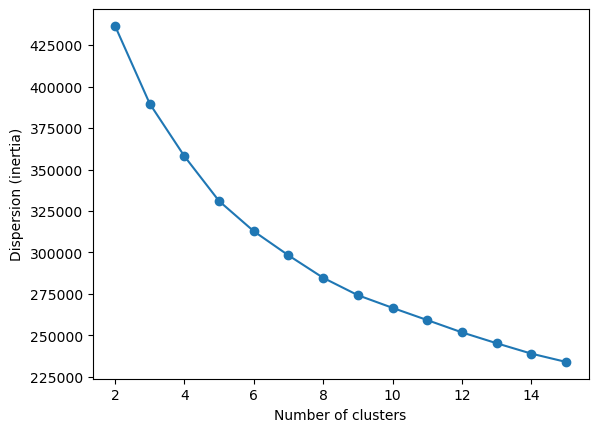

In [27]:
kmeans_workflow.find_optimal_k(X_scaled, K_range=15)

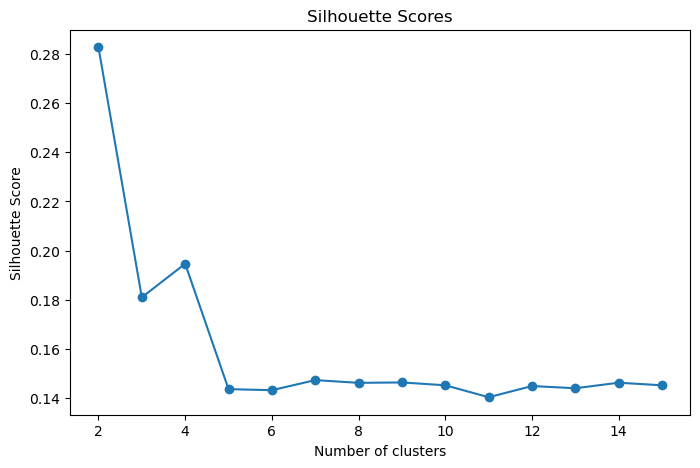

In [28]:
kmeans_workflow.silhouette(X_scaled, K_range=15)

In [33]:
kmeans = KMeans(n_clusters= 7,random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(kmeans)
kmeans_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()


,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,share_fish,share_hygiene,share_videogames,share_petfood,share_food_basic,share_protein,share_leisure,share_adult_drinks,share_home_care,cluster_kmeans
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,0.011458,0.029693,0.013771,0.020656,0.668478,0.012964,0.258687,0.009521,0.050350,5
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,0.000741,0.092918,0.016458,0.032867,0.802600,0.002867,0.064054,0.004695,0.125785,1
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,0.017557,0.032607,0.006496,0.014277,0.840118,0.098913,0.006496,0.007589,0.046884,5
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,0.072432,0.032437,0.110754,0.012306,0.557384,0.137440,0.184658,0.075776,0.044743,2
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,0.039346,0.011513,0.048765,0.017095,0.393805,0.080746,0.469008,0.027833,0.028608,2


In [34]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
3    8740
5    8308
1    5597
2    3498
4    2694
6    1934
0    1472
Name: count, dtype: int64

In [35]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [36]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6
customer_age,57.352582,57.912989,54.676958,57.321854,57.979213,48.678142,58.816960
total_children,1.935462,1.903520,0.547742,1.440389,6.009651,1.854598,1.646846
distinct_stores_visited,3.423913,3.412542,1.537164,4.371053,3.218634,2.203298,3.744054
percentage_of_products_bought_promotion,0.128084,0.129623,0.261700,0.549232,0.209956,0.285210,0.433892
hour_sin,-0.015358,0.008373,-0.496347,-0.388128,0.382736,0.677025,-0.025322
hour_cos,-0.536942,-0.591202,0.150604,-0.336608,-0.768432,-0.486332,-0.436103
share_groceries,0.356799,0.671091,0.360244,0.765586,0.644949,0.755770,0.386346
share_vegetables,0.195618,0.093226,0.009119,0.021033,0.022427,0.021138,0.053274
share_meat,0.011159,0.007111,0.039519,0.037367,0.041801,0.035445,0.102358
share_fish,0.010488,0.005997,0.037533,0.023374,0.036866,0.029441,0.073978


In [37]:
experimental_hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(experimental_hierarchical)

In [ ]:
hierarchical_workflow.find_optimal_k(X_scaled)

In [ ]:
hierarchical_workflow.silhouette(X_scaled, K_range=10)

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(hierarchical)

hierarchical_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()

#fazer comparação dos modelos... aquela matrix para comparar os clusters

In [22]:
pca = PCA(n_components=2, random_state=42)

pca_workflow = PCAWorkflow(pca)
pca_workflow.fit_and_transformation(X_scaled)

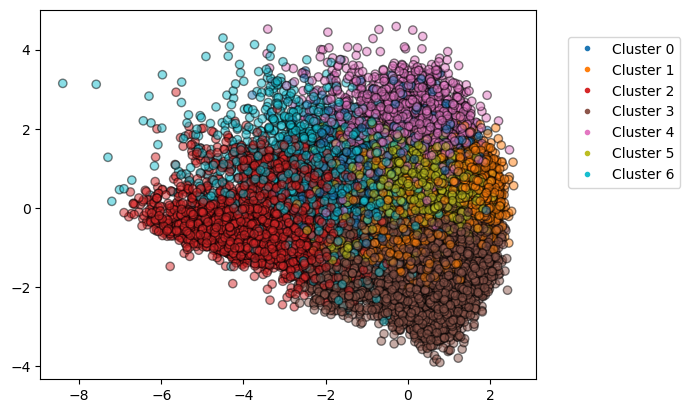

In [38]:
pca_workflow.plot(dataset["cluster_kmeans"])

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_workflow = TSNEWorkflow(tsne)
tsne_workflow.fit_and_transformation(X_scaled)

In [ ]:
tsne_workflow.plot(dataset["cluster_kmeans"])